# 05 - Statistical and Diagnostic Analysis

## Objective

This notebook provides the inferential and descriptive evidence for **RQ2** and
**RQ3**, plus preliminary association evidence for **RQ1**. It uses the cleaned
2025 BTS dataset to test schedule-time factors and compare delay rates across
airlines, airports, routes, departure periods, and seasons.

Predictive performance is finalized in Notebooks 07–08, SHAP explainability in
Notebook 09, and operational prioritization in Notebook 10. Statistical
association is not interpreted as causation or as proof of predictive accuracy.


#### Load project configuration

In [1]:
from __future__ import annotations

import importlib.util
import os
from pathlib import Path

from dotenv import dotenv_values

bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not bootstrap.is_file():
    bootstrap = Path.cwd() / "import_path.py"
spec = importlib.util.spec_from_file_location("import_path", bootstrap)
import_path = importlib.util.module_from_spec(spec)
spec.loader.exec_module(import_path)

from config import project_config as cfg

DATABRICKS_PROFILE = os.getenv(
    "DATABRICKS_CONFIG_PROFILE",
    "capstone-serverless",
)
api_env_candidates = [
    Path.cwd() / "api" / ".env",
    Path.cwd().parent / "api" / ".env",
]
api_env_path = next(
    (candidate for candidate in api_env_candidates if candidate.is_file()),
    None,
)
api_credentials = dotenv_values(api_env_path) if api_env_path else {}
local_host = str(
    api_credentials.get("DATABRICKS_SERVER_HOSTNAME", "")
).strip()
local_token = str(
    api_credentials.get("DATABRICKS_ACCESS_TOKEN", "")
).strip()
if local_host and not local_host.startswith("http"):
    local_host = f"https://{local_host}"

try:
    spark
except NameError:
    from databricks.connect import DatabricksSession

    builder = DatabricksSession.builder.serverless()
    if local_host and local_token:
        builder = builder.host(local_host).token(local_token)
    else:
        builder = builder.profile(DATABRICKS_PROFILE)
    spark = builder.getOrCreate()

print("Project configuration and Spark session loaded successfully.")
print(f"Source table: {cfg.CLEAN_TABLE}")
print(f"Results table: {cfg.STATISTICAL_RESULTS_TABLE}")
print(f"Significance level: {cfg.STATISTICAL_SIGNIFICANCE_ALPHA}")


Project configuration and Spark session loaded successfully.
Source table: workspace.default.flights_clean
Results table: workspace.default.statistical_analysis_results
Significance level: 0.05


#### Load and validate the cleaned dataset

The statistical analysis uses the managed `flights_clean` table produced by the data-cleaning notebook. Only completed operational flights are retained for hypothesis testing.

In [2]:
from pyspark.sql import DataFrame
from pyspark.sql import functions as F


def require_table(table_name: str) -> None:
    """Raise an error when a required Unity Catalog table is unavailable."""
    if not spark.catalog.tableExists(table_name):
        raise RuntimeError(
            f"Required table '{table_name}' was not found. "
            "Run the data-cleaning notebook before continuing."
        )


require_table(cfg.CLEAN_TABLE)

df_clean: DataFrame = spark.table(cfg.CLEAN_TABLE)

clean_row_count = df_clean.count()
missing_columns = sorted(
    set(cfg.FEATURE_INPUT_COLUMNS) - set(df_clean.columns)
)

if missing_columns:
    raise ValueError(
        "Statistical-analysis validation failed. "
        f"Missing required columns: {missing_columns}"
    )

print("Cleaned dataset loaded and validated successfully.")
print(f"Total records: {clean_row_count:,}")
print(f"Prediction target: {cfg.TARGET_COLUMN}")


Cleaned dataset loaded and validated successfully.
Total records: 7,001,611
Prediction target: ARR_DEL15


#### Create the analysis population

Cancelled and diverted flights are excluded because the target variable represents arrival delay for completed flights. Schedule-time diagnostic fields are derived for statistical testing.

In [3]:
# Build the SEASON and TIME_OF_DAY expressions from the shared project
# configuration (cfg.SEASON_MONTH_GROUPS / cfg.TIME_OF_DAY_BUCKETS) so this
# notebook's diagnostic categories always match the model feature definitions.

season_expression = None
for season_name, season_months in cfg.SEASON_MONTH_GROUPS.items():
    month_condition = F.col(cfg.MONTH_COLUMN).isin(*season_months)
    if season_expression is None:
        season_expression = F.when(month_condition, season_name)
    else:
        season_expression = season_expression.when(month_condition, season_name)

time_of_day_expression = None
for bucket in cfg.TIME_OF_DAY_BUCKETS:
    hour_condition = F.col(cfg.DEP_HOUR_COLUMN).between(
        bucket["start_hour"], bucket["end_hour"]
    )
    if time_of_day_expression is None:
        time_of_day_expression = F.when(hour_condition, bucket["label"])
    else:
        time_of_day_expression = time_of_day_expression.when(
            hour_condition, bucket["label"]
        )

df_analysis = (
    df_clean
    .filter(
        (F.col(cfg.CANCELLED_COLUMN) == cfg.MODEL_ELIGIBLE_STATUS_VALUE)
        & (F.col(cfg.DIVERTED_COLUMN) == cfg.MODEL_ELIGIBLE_STATUS_VALUE)
    )
    .withColumn(
        # CRS_DEP_TIME occasionally uses "2400" for a scheduled midnight
        # departure; floor(.../100) alone would yield an invalid hour of 24,
        # so the result is taken modulo 24 to normalize midnight to hour 0.
        cfg.DEP_HOUR_COLUMN,
        (F.floor(F.col(cfg.SCHEDULED_DEPARTURE_COLUMN) / 100) % 24).cast("int"),
    )
    .withColumn(
        cfg.ROUTE_COLUMN,
        F.concat_ws(
            "-",
            F.col(cfg.ORIGIN_COLUMN),
            F.col(cfg.DESTINATION_COLUMN),
        ),
    )
    .withColumn(
        cfg.IS_WEEKEND_COLUMN,
        F.when(
            F.col(cfg.DAY_OF_WEEK_COLUMN).isin(*cfg.WEEKEND_DAYS),
            F.lit(1),
        ).otherwise(F.lit(0)),
    )
    .withColumn(cfg.SEASON_COLUMN, season_expression)
    .withColumn(cfg.TIME_OF_DAY_COLUMN, time_of_day_expression)
)

analysis_row_count = df_analysis.count()

analysis_summary = spark.createDataFrame(
    [
        (
            clean_row_count,
            analysis_row_count,
            clean_row_count - analysis_row_count,
        )
    ],
    schema="CLEAN_ROWS long, ANALYSIS_ROWS long, EXCLUDED_ROWS long",
)

display(analysis_summary)


,CLEAN_ROWS,ANALYSIS_ROWS,EXCLUDED_ROWS
0,7001611,6879483,122128


#### Define the refined research questions and hypotheses

The wording below is the authoritative version from the refined project proposal.

| ID | Research Question |
|---|---|
| RQ1 | How accurately can schedule-time flight information predict whether a flight will arrive at least 15 minutes late? |
| RQ2 | Which scheduling, airline, airport, route, and temporal factors are most strongly associated with arrival-delay risk? |
| RQ3 | How do delay rates differ across airlines, airports, routes, departure periods, and seasons? |
| RQ4 | How can SHAP explanations help users understand the factors driving overall and individual flight-delay predictions? |
| RQ5 | Can an optimization-based prioritization method identify more actually delayed flights than random selection or simple rule-based prioritization when operational capacity is limited? |

| Hypothesis | Null Hypothesis (H0) | Alternative Hypothesis (H1) | Final evaluation |
|---|---|---|---|
| H1 | Schedule-time information provides no predictive improvement over naive baselines on unseen data. | Schedule-time information provides predictive improvement over naive baselines on unseen data. | Notebook 08 |
| H2 | The listed schedule-time factors have no association with arrival-delay risk. | At least one listed schedule-time factor is associated with arrival-delay risk. | Notebook 05 |
| H3 | Delay rates do not differ across the listed operational groups. | At least one listed operational group has a different delay rate. | Notebooks 04–05 |
| H5 | At equal review capacity, optimization does not capture more actual delays than random selection and a simple top-risk rule. | At equal review capacity, optimization captures more actual delays than both comparison strategies. | Notebook 10 |

RQ4 is an explainability question rather than a classical inferential hypothesis.
It is answered by demonstrating valid global and local SHAP explanations in
Notebook 09; no unperformed user study or causal effect is claimed.


#### Create the statistical analysis sample

Because the full dataset contains millions of records, a reproducible uniform sample is used for inferential tests executed in Python. Aggregated Spark summaries are used where appropriate.

In [4]:
import importlib.util
from pathlib import Path

_bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not _bootstrap.is_file():
    _bootstrap = Path.cwd() / "import_path.py"
_spec = importlib.util.spec_from_file_location("import_path", _bootstrap)
_ip = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_ip)

from utils import statistical_analysis as stat


analysis_columns = [
    cfg.TARGET_COLUMN,
    cfg.DISTANCE_COLUMN,
    cfg.MONTH_COLUMN,
    cfg.DAY_OF_WEEK_COLUMN,
    cfg.AIRLINE_COLUMN,
    cfg.ORIGIN_COLUMN,
    cfg.DESTINATION_COLUMN,
    cfg.ROUTE_COLUMN,
    cfg.SEASON_COLUMN,
    cfg.TIME_OF_DAY_COLUMN,
    cfg.IS_WEEKEND_COLUMN,
    cfg.DEP_HOUR_COLUMN,
]

analysis_sample = (
    df_analysis
    .select(*analysis_columns)
    .sample(
        withReplacement=False,
        fraction=cfg.STATISTICAL_SAMPLE_FRACTION,
        seed=cfg.RANDOM_SEED,
    )
)

analysis_pdf = analysis_sample.toPandas()

print(f"Analysis sample rows: {len(analysis_pdf):,}")
print(
    f"Observed delay rate: "
    f"{analysis_pdf[cfg.TARGET_COLUMN].mean():.4f}"
)

display(analysis_sample.limit(5))


Analysis sample rows: 343,570
Observed delay rate: 0.2234


,ARR_DEL15,DISTANCE,MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,ROUTE,SEASON,TIME_OF_DAY,IS_WEEKEND,DEP_HOUR
0,0,808.0,4,1,AA,MCI,CLT,MCI-CLT,Spring,Evening,0,18
1,1,544.0,4,1,AA,CLT,LGA,CLT-LGA,Spring,Evening,0,18
2,0,328.0,4,1,AA,BNA,CLT,BNA-CLT,Spring,Overnight,0,5
3,1,733.0,4,1,AA,LGA,ORD,LGA-ORD,Spring,Afternoon,0,12
4,0,868.0,4,1,AA,DFW,PHX,DFW-PHX,Spring,Afternoon,0,16


#### Helper functions for grouped categorical tests

High-cardinality categorical variables are grouped into the most frequent categories plus an `OTHER` bucket so chi-square expected frequencies remain valid.

In [5]:
import pandas as pd


def bucket_top_categories(
    frame,
    column_name: str,
    top_n: int,
) -> str:
    grouped_column = f"{column_name}_GROUPED"
    top_values = (
        frame[column_name]
        .value_counts()
        .head(top_n)
        .index
        .tolist()
    )
    frame[grouped_column] = frame[column_name].apply(
        lambda value: value if value in top_values else "OTHER"
    )
    return grouped_column


def run_categorical_test(
    *,
    research_question: str,
    hypothesis_id: str,
    null_hypothesis: str,
    alternative_hypothesis: str,
    frame,
    factor_column: str,
    top_n: int | None = None,
) -> dict:
    working_frame = frame.copy()
    test_column = factor_column

    if top_n is not None:
        test_column = bucket_top_categories(
            working_frame,
            factor_column,
            top_n,
        )

    contingency_table = pd.crosstab(
        working_frame[test_column],
        working_frame[cfg.TARGET_COLUMN],
    )
    test_output = stat.chi_square_independence(
        contingency_table,
        min_expected_frequency=cfg.STATISTICAL_MIN_EXPECTED_FREQUENCY,
    )
    return stat.build_test_result_row(
        research_question=research_question,
        hypothesis_id=hypothesis_id,
        null_hypothesis=null_hypothesis,
        alternative_hypothesis=alternative_hypothesis,
        factor=test_column,
        test_output=test_output,
        alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
    )


#### RQ2 / H2 — Factors associated with arrival-delay risk

The tests cover the factor families named in RQ2: scheduling, airline, airport,
route, and temporal information. Chi-square tests with Cramér's V are used for
categorical factors; distance is examined with correlation and a Welch test.
Because the dataset is large, practical effect size is interpreted together
with statistical significance.


In [6]:
rq2_results = []
H2_NULL = (
    "Scheduling, airline, airport, route, and temporal factors have no "
    "statistically significant association with arrival-delay risk."
)
H2_ALTERNATIVE = (
    "At least one scheduling, airline, airport, route, or temporal factor "
    "has a statistically significant association with arrival-delay risk."
)

distance_test = stat.pearson_correlation(
    analysis_pdf[cfg.DISTANCE_COLUMN],
    analysis_pdf[cfg.TARGET_COLUMN],
)
rq2_results.append(
    stat.build_test_result_row(
        research_question="RQ2",
        hypothesis_id="H2",
        null_hypothesis=H2_NULL,
        alternative_hypothesis=H2_ALTERNATIVE,
        factor=cfg.DISTANCE_COLUMN,
        test_output=distance_test,
        alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
    )
)

categorical_factor_settings = [
    (cfg.MONTH_COLUMN, None),
    (cfg.DAY_OF_WEEK_COLUMN, None),
    (cfg.SEASON_COLUMN, None),
    (cfg.TIME_OF_DAY_COLUMN, None),
    (cfg.IS_WEEKEND_COLUMN, None),
    (cfg.AIRLINE_COLUMN, cfg.STATISTICAL_TOP_AIRLINES),
    (cfg.ORIGIN_COLUMN, cfg.STATISTICAL_TOP_AIRPORTS),
    (cfg.DESTINATION_COLUMN, cfg.STATISTICAL_TOP_DEST_AIRPORTS),
    (cfg.ROUTE_COLUMN, cfg.STATISTICAL_TOP_ROUTES),
]

for factor_column, top_n in categorical_factor_settings:
    rq2_results.append(
        run_categorical_test(
            research_question="RQ2",
            hypothesis_id="H2",
            null_hypothesis=H2_NULL,
            alternative_hypothesis=H2_ALTERNATIVE,
            frame=analysis_pdf,
            factor_column=factor_column,
            top_n=top_n,
        )
    )

distance_t_test = stat.independent_t_test(
    analysis_pdf.loc[
        analysis_pdf[cfg.TARGET_COLUMN] == 0,
        cfg.DISTANCE_COLUMN,
    ],
    analysis_pdf.loc[
        analysis_pdf[cfg.TARGET_COLUMN] == 1,
        cfg.DISTANCE_COLUMN,
    ],
)
rq2_results.append(
    stat.build_test_result_row(
        research_question="RQ2",
        hypothesis_id="H2",
        null_hypothesis=H2_NULL,
        alternative_hypothesis=H2_ALTERNATIVE,
        factor=f"{cfg.DISTANCE_COLUMN} (delayed vs on-time)",
        test_output=distance_t_test,
        alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
    )
)

rq2_results_df = pd.DataFrame(rq2_results)
display(spark.createDataFrame(rq2_results_df))


,research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,effect_size_interpretation,alpha,decision,assumptions_met
0,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",DISTANCE,Pearson Correlation,0.004392,0.010047,0.004392,|Pearson r|,Negligible,0.05,Reject H0,True
1,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",MONTH,Chi-Square Test of Independence,2655.887472,0.000000,0.087922,Cramer's V,Negligible,0.05,Reject H0,True
2,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",DAY_OF_WEEK,Chi-Square Test of Independence,1306.469789,0.000000,0.061665,Cramer's V,Negligible,0.05,Reject H0,True
3,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",SEASON,Chi-Square Test of Independence,1433.780697,0.000000,0.064600,Cramer's V,Negligible,0.05,Reject H0,True
4,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",TIME_OF_DAY,Chi-Square Test of Independence,10585.274981,0.000000,0.175527,Cramer's V,Small,0.05,Reject H0,True
5,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",IS_WEEKEND,Chi-Square Test of Independence,226.050455,0.000000,0.025650,Cramer's V,Negligible,0.05,Reject H0,True
6,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",OP_UNIQUE_CARRIER_GROUPED,Chi-Square Test of Independence,937.599817,0.000000,0.052240,Cramer's V,Negligible,0.05,Reject H0,True
7,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",ORIGIN_GROUPED,Chi-Square Test of Independence,1445.368379,0.000000,0.064861,Cramer's V,Negligible,0.05,Reject H0,True
8,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",DEST_GROUPED,Chi-Square Test of Independence,714.948138,0.000000,0.045617,Cramer's V,Negligible,0.05,Reject H0,True
9,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with 

#### RQ2 / H2 — Chi-square test for scheduled departure hour

Because `ARR_DEL15` is binary, a chi-square test of independence is used to determine whether delay outcomes differ across scheduled departure hours. Spark aggregates the complete analysis population into a small 24-hour by 2-class contingency table before the statistical test is run in Python. Using the full population prevents rare overnight hours from producing insufficient expected frequencies in the 5% analysis sample.

In [7]:
hour_contingency_pdf = (
    df_analysis
    .groupBy(cfg.DEP_HOUR_COLUMN)
    .pivot(cfg.TARGET_COLUMN, [0, 1])
    .count()
    .fillna(0)
    .orderBy(cfg.DEP_HOUR_COLUMN)
    .toPandas()
    .set_index(cfg.DEP_HOUR_COLUMN)
)

hour_chi_square = stat.chi_square_independence(
    hour_contingency_pdf,
    min_expected_frequency=cfg.STATISTICAL_MIN_EXPECTED_FREQUENCY,
)

hour_chi_square_row = stat.build_test_result_row(
    research_question="RQ2",
    hypothesis_id="H2",
    null_hypothesis=H2_NULL,
    alternative_hypothesis=H2_ALTERNATIVE,
    factor=cfg.DEP_HOUR_COLUMN,
    test_output=hour_chi_square,
    alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
)

rq2_results.append(hour_chi_square_row)
rq2_results_df = pd.DataFrame(rq2_results)
display(spark.createDataFrame(pd.DataFrame([hour_chi_square_row])))

rq2_categorical_ranking = (
    rq2_results_df[
        rq2_results_df["effect_size_label"] == "Cramer's V"
    ][
        [
            "factor",
            "effect_size",
            "effect_size_interpretation",
            "p_value",
            "decision",
        ]
    ]
    .sort_values("effect_size", ascending=False)
    .reset_index(drop=True)
)
print("RQ2 categorical factors ranked by Cramer's V:")
display(rq2_categorical_ranking)


,research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,effect_size_interpretation,alpha,decision,assumptions_met
0,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",DEP_HOUR,Chi-Square Test of Independence,235257.830992,0.0,0.184924,Cramer's V,Small,0.05,Reject H0,True


RQ2 categorical factors ranked by Cramer's V:


,factor,effect_size,effect_size_interpretation,p_value,decision
0,DEP_HOUR,0.184924,Small,0.0,Reject H0
1,TIME_OF_DAY,0.175527,Small,0.0,Reject H0
2,MONTH,0.087922,Negligible,0.0,Reject H0
3,ORIGIN_GROUPED,0.064861,Negligible,0.0,Reject H0
4,SEASON,0.064600,Negligible,0.0,Reject H0
5,DAY_OF_WEEK,0.061665,Negligible,0.0,Reject H0
6,OP_UNIQUE_CARRIER_GROUPED,0.052240,Negligible,0.0,Reject H0
7,DEST_GROUPED,0.045617,Negligible,0.0,Reject H0
8,ROUTE_GROUPED,0.028531,Negligible,0.0,Reject H0
9,IS_WEEKEND,0.025650,Negligible,0.0,Reject H0


#### RQ3 / H3 — Operational delay-rate differences

Chi-square tests evaluate whether the binary delay outcome differs across
airlines, origin and destination airports, routes, departure periods, and
seasons. The next section reports full-population delay rates so RQ3 answers
both whether differences exist and how large the observed rates are.


In [8]:
H3_NULL = (
    "Delay rates do not differ across airlines, airports, routes, departure "
    "periods, or seasons."
)
H3_ALTERNATIVE = (
    "At least one airline, airport, route, departure period, or season has a "
    "different delay rate."
)

rq3_factor_settings = [
    (cfg.AIRLINE_COLUMN, cfg.STATISTICAL_TOP_AIRLINES),
    (cfg.ORIGIN_COLUMN, cfg.STATISTICAL_TOP_AIRPORTS),
    (cfg.DESTINATION_COLUMN, cfg.STATISTICAL_TOP_DEST_AIRPORTS),
    (cfg.ROUTE_COLUMN, cfg.STATISTICAL_TOP_ROUTES),
    (cfg.TIME_OF_DAY_COLUMN, None),
    (cfg.SEASON_COLUMN, None),
]

rq3_results = [
    run_categorical_test(
        research_question="RQ3",
        hypothesis_id="H3",
        null_hypothesis=H3_NULL,
        alternative_hypothesis=H3_ALTERNATIVE,
        frame=analysis_pdf,
        factor_column=factor_column,
        top_n=top_n,
    )
    for factor_column, top_n in rq3_factor_settings
]

rq3_results_df = pd.DataFrame(rq3_results)
display(spark.createDataFrame(rq3_results_df))


,research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,effect_size_interpretation,alpha,decision,assumptions_met
0,RQ3,H3,"Delay rates do not differ across airlines, airports, routes, departure periods, or seasons.","At least one airline, airport, route, departure period, or season has a different delay rate.",OP_UNIQUE_CARRIER_GROUPED,Chi-Square Test of Independence,937.599817,0.0,0.052240,Cramer's V,Negligible,0.05,Reject H0,True
1,RQ3,H3,"Delay rates do not differ across airlines, airports, routes, departure periods, or seasons.","At least one airline, airport, route, departure period, or season has a different delay rate.",ORIGIN_GROUPED,Chi-Square Test of Independence,1445.368379,0.0,0.064861,Cramer's V,Negligible,0.05,Reject H0,True
2,RQ3,H3,"Delay rates do not differ across airlines, airports, routes, departure periods, or seasons.","At least one airline, airport, route, departure period, or season has a different delay rate.",DEST_GROUPED,Chi-Square Test of Independence,714.948138,0.0,0.045617,Cramer's V,Negligible,0.05,Reject H0,True
3,RQ3,H3,"Delay rates do not differ across airlines, airports, routes, departure periods, or seasons.","At least one airline, airport, route, departure period, or season has a different delay rate.",ROUTE_GROUPED,Chi-Square Test of Independence,279.674081,0.0,0.028531,Cramer's V,Negligible,0.05,Reject H0,True
4,RQ3,H3,"Delay rates do not differ across airlines, airports, routes, departure periods, or seasons.","At least one airline, airport, route, departure period, or season has a different delay rate.",TIME_OF_DAY,Chi-Square Test of Independence,10585.274981,0.0,0.175527,Cramer's V,Small,0.05,Reject H0,True
5,RQ3,H3,"Delay rates do not differ across airlines, airports, routes, departure periods, or seasons.","At least one airline, airport, route, departure period, or season has a different delay rate.",SEASON,Chi-Square Test of Independence,1433.780697,0.0,0.064600,Cramer's V,Negligible,0.05,Reject H0,True


#### RQ3 — Full-population delay-rate comparisons

These summaries use all eligible completed flights rather than the Python
sample. High-cardinality factors are limited to their most frequent groups for
readability. `DELAY_RATE` is the observed proportion with `ARR_DEL15 = 1`.


In [9]:
def summarize_delay_rates(
    factor_column: str,
    top_n: int | None = None,
) -> pd.DataFrame:
    summary = (
        df_analysis
        .filter(F.col(factor_column).isNotNull())
        .groupBy(factor_column)
        .agg(
            F.count("*").alias("TOTAL_FLIGHTS"),
            F.sum(cfg.TARGET_COLUMN).cast("long").alias("DELAYED_FLIGHTS"),
            F.avg(cfg.TARGET_COLUMN).alias("DELAY_RATE"),
        )
    )
    if top_n is not None:
        summary = summary.orderBy(F.col("TOTAL_FLIGHTS").desc()).limit(top_n)

    return (
        summary
        .select(
            F.lit(factor_column).alias("FACTOR"),
            F.col(factor_column).cast("string").alias("CATEGORY"),
            "TOTAL_FLIGHTS",
            "DELAYED_FLIGHTS",
            "DELAY_RATE",
        )
        .toPandas()
    )


rq3_rate_specs = [
    (cfg.AIRLINE_COLUMN, cfg.STATISTICAL_TOP_AIRLINES),
    (cfg.ORIGIN_COLUMN, cfg.STATISTICAL_TOP_AIRPORTS),
    (cfg.DESTINATION_COLUMN, cfg.STATISTICAL_TOP_DEST_AIRPORTS),
    (cfg.ROUTE_COLUMN, cfg.STATISTICAL_TOP_ROUTES),
    (cfg.TIME_OF_DAY_COLUMN, None),
    (cfg.SEASON_COLUMN, None),
]

rq3_delay_rates_pdf = pd.concat(
    [
        summarize_delay_rates(factor_column, top_n)
        for factor_column, top_n in rq3_rate_specs
    ],
    ignore_index=True,
)
rq3_delay_rates_pdf["DELAY_RATE_PCT"] = (
    rq3_delay_rates_pdf["DELAY_RATE"] * 100
).round(2)

display(
    spark.createDataFrame(rq3_delay_rates_pdf)
    .orderBy("FACTOR", F.col("DELAY_RATE").desc())
)


,FACTOR,CATEGORY,TOTAL_FLIGHTS,DELAYED_FLIGHTS,DELAY_RATE,DELAY_RATE_PCT
0,DEST,DCA,136407,38685,0.283600,28.36
1,DEST,LGA,130999,34243,0.261399,26.14
2,DEST,BOS,140277,36616,0.261026,26.10
3,DEST,ORD,320097,81247,0.253820,25.38
4,DEST,DFW,305342,75577,0.247516,24.75
5,DEST,MCO,157555,38068,0.241617,24.16
6,DEST,SFO,143165,34510,0.241051,24.11
7,DEST,DEN,313484,73935,0.235849,23.58
8,DEST,SEA,162971,34754,0.213253,21.33
9,DEST,LAS,182167,38059,0.208924,20.89


#### RQ1 — Preliminary schedule-time association evidence

These exploratory chi-square tests only show that selected schedule-time
variables are associated with delay outcomes. They do **not** test predictive
accuracy. RQ1 and H1 are answered by chronological model development in
Notebook 07 and the untouched holdout evaluation in Notebook 08.


In [10]:
rq1_results = [
    run_categorical_test(
        research_question="RQ1",
        hypothesis_id="RQ1-Preliminary",
        null_hypothesis="The selected schedule-time factor is not associated with the arrival-delay outcome.",
        alternative_hypothesis="The selected schedule-time factor is associated with the arrival-delay outcome.",
        frame=analysis_pdf,
        factor_column=cfg.TIME_OF_DAY_COLUMN,
    ),
    run_categorical_test(
        research_question="RQ1",
        hypothesis_id="RQ1-Preliminary",
        null_hypothesis="The selected schedule-time factor is not associated with the arrival-delay outcome.",
        alternative_hypothesis="The selected schedule-time factor is associated with the arrival-delay outcome.",
        frame=analysis_pdf,
        factor_column=cfg.SEASON_COLUMN,
    ),
    run_categorical_test(
        research_question="RQ1",
        hypothesis_id="RQ1-Preliminary",
        null_hypothesis="The selected schedule-time factor is not associated with the arrival-delay outcome.",
        alternative_hypothesis="The selected schedule-time factor is associated with the arrival-delay outcome.",
        frame=analysis_pdf,
        factor_column=cfg.IS_WEEKEND_COLUMN,
    ),
]

rq1_results_df = pd.DataFrame(rq1_results)
display(spark.createDataFrame(rq1_results_df))


,research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,effect_size_interpretation,alpha,decision,assumptions_met
0,RQ1,RQ1-Preliminary,The selected schedule-time factor is not associated with the arrival-delay outcome.,The selected schedule-time factor is associated with the arrival-delay outcome.,TIME_OF_DAY,Chi-Square Test of Independence,10585.274981,0.0,0.175527,Cramer's V,Small,0.05,Reject H0,True
1,RQ1,RQ1-Preliminary,The selected schedule-time factor is not associated with the arrival-delay outcome.,The selected schedule-time factor is associated with the arrival-delay outcome.,SEASON,Chi-Square Test of Independence,1433.780697,0.0,0.064600,Cramer's V,Negligible,0.05,Reject H0,True
2,RQ1,RQ1-Preliminary,The selected schedule-time factor is not associated with the arrival-delay outcome.,The selected schedule-time factor is associated with the arrival-delay outcome.,IS_WEEKEND,Chi-Square Test of Independence,226.050455,0.0,0.025650,Cramer's V,Negligible,0.05,Reject H0,True


#### Extended diagnostic analytics

The sections below extend the inferential tests with distribution-level and correlation-based diagnostics requested in the project review:

- Kruskal-Wallis testing for continuous arrival-delay minutes across airlines
- Dunn post-hoc pairwise comparisons with Bonferroni correction
- Spearman correlation analysis for skewed operational delay variables

These diagnostics use completed-flight outcome fields for explanatory analysis only. They are not used as predictive model inputs.

#### Extended diagnostic sample

The same reproducible analysis sample is enriched with arrival- and departure-delay minute fields for distribution and correlation diagnostics.

In [11]:
extended_analysis_columns = analysis_columns + [
    cfg.ARRIVAL_DELAY_COLUMN,
    cfg.DEPARTURE_DELAY_COLUMN,
    cfg.TAXI_OUT_COLUMN,
    cfg.TAXI_IN_COLUMN,
    cfg.AIR_TIME_COLUMN,
]

extended_analysis_pdf = (
    df_analysis
    .select(*extended_analysis_columns)
    .sample(
        withReplacement=False,
        fraction=cfg.STATISTICAL_SAMPLE_FRACTION,
        seed=cfg.RANDOM_SEED + 1,
    )
    .toPandas()
)

print(
    f"Extended diagnostic sample rows: {len(extended_analysis_pdf):,}"
)


Extended diagnostic sample rows: 343,545


#### RQ3 / H3 — Arrival-delay-minute differences by airline

Kruskal-Wallis evaluates whether continuous arrival-delay-minute distributions
differ across airline groups. Epsilon-squared is reported so statistical
significance can be separated from practical magnitude.


In [12]:
extended_results = []

airline_grouped_column = bucket_top_categories(
    extended_analysis_pdf,
    cfg.AIRLINE_COLUMN,
    cfg.STATISTICAL_TOP_AIRLINES,
)

airline_delay_groups = [
    group[cfg.ARRIVAL_DELAY_COLUMN]
    for _, group in extended_analysis_pdf.groupby(airline_grouped_column)
]

kruskal_test = stat.kruskal_wallis_test(airline_delay_groups)
extended_results.append(
    stat.build_test_result_row(
        research_question="RQ3",
        hypothesis_id="H3",
        null_hypothesis=H3_NULL,
        alternative_hypothesis=H3_ALTERNATIVE,
        factor=f"{cfg.ARRIVAL_DELAY_COLUMN} by {airline_grouped_column}",
        test_output=kruskal_test,
        alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
    )
)

display(spark.createDataFrame(pd.DataFrame([extended_results[-1]])))


,research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,effect_size_interpretation,alpha,decision,assumptions_met
0,RQ3,H3,"Delay rates do not differ across airlines, airports, routes, departure periods, or seasons.","At least one airline, airport, route, departure period, or season has a different delay rate.",ARR_DELAY by OP_UNIQUE_CARRIER_GROUPED,Kruskal-Wallis H-Test,1452.939351,0.0,0.0042,Epsilon-squared,Negligible,0.05,Reject H0,True


#### Dunn post-hoc pairwise comparisons

When the Kruskal-Wallis test is significant, Dunn's test identifies which airline groups differ in arrival-delay distributions. Bonferroni correction controls the family-wise error rate.

In [13]:
import scikit_posthocs as sp


In [14]:
airline_posthoc_frame = extended_analysis_pdf[
    [airline_grouped_column, cfg.ARRIVAL_DELAY_COLUMN]
].dropna()

dunn_results = sp.posthoc_dunn(
    airline_posthoc_frame,
    val_col=cfg.ARRIVAL_DELAY_COLUMN,
    group_col=airline_grouped_column,
    p_adjust="bonferroni",
)

display(dunn_results)

significant_pairs = []
airlines = dunn_results.index.tolist()

for i, airline_one in enumerate(airlines):
    for j in range(i + 1, len(airlines)):
        adjusted_p_value = float(dunn_results.iloc[i, j])
        if adjusted_p_value < cfg.STATISTICAL_SIGNIFICANCE_ALPHA:
            significant_pairs.append(
                {
                    "airline_one": airline_one,
                    "airline_two": airlines[j],
                    "adjusted_p_value": round(adjusted_p_value, 6),
                }
            )

significant_pairs_df = pd.DataFrame(significant_pairs).sort_values(
    "adjusted_p_value"
)

print(
    f"Significant airline pairs after Bonferroni correction: "
    f"{len(significant_pairs_df):,}"
)
display(significant_pairs_df.head(20))


,AA,AS,B6,DL,MQ,OH,OO,OTHER,UA,WN,YX
AA,1.000000e+00,1.000000e+00,1.226477e-08,8.361454e-120,2.655200e-04,1.000000e+00,3.938935e-45,1.803330e-05,1.505369e-32,5.088704e-07,6.300757e-53
AS,1.000000e+00,1.000000e+00,2.527195e-05,3.849819e-47,2.536979e-02,1.000000e+00,8.700462e-19,2.811215e-02,1.070719e-13,2.923927e-02,1.088038e-29
B6,1.226477e-08,2.527195e-05,1.000000e+00,4.091036e-14,1.000000e+00,2.122867e-06,2.158702e-01,5.516358e-01,1.000000e+00,1.654043e-21,7.024044e-08
DL,8.361454e-120,3.849819e-47,4.091036e-14,1.000000e+00,1.047672e-27,7.919863e-51,6.272438e-14,3.556668e-51,1.888912e-21,1.034964e-214,1.000000e+00
MQ,2.655200e-04,2.536979e-02,1.000000e+00,1.047672e-27,1.000000e+00,3.710275e-03,2.013962e-06,1.000000e+00,2.449989e-03,1.135838e-15,1.123406e-15
OH,1.000000e+00,1.000000e+00,2.122867e-06,7.919863e-51,3.710275e-03,1.000000e+00,3.756720e-21,3.135739e-03,9.803003e-16,2.401221e-01,3.149818e-32
OO,3.938935e-45,8.700462e-19,2.158702e-01,6.272438e-14,2.013962e-06,3.756720e-21,1.000000e+00,5.501690e-13,1.000000e+00,1.657852e-96,1.315301e-04
OTHER,1.803330e-05,2.811215e-02,5.516358e-01,3.556668e-51,1.000000e+00,3.135739e-03,5.501690e-13,1.000000e+00,1.960504e-07,1.852281e-23,2.418498e-24
UA,1.505369e-32,1.070719e-13,1.000000e+00,1.888912e-21,2.449989e-03,9.803003e-16,1.000000e+00,1.960504e-07,1.000000e+00,2.233252e-75,4.230769e-08
WN,5.088704e-07,2.923927e-02,1.654043e-21,1.034964e-214,1.135838e-15,2.401221e-01,1.657852e-96,1.852281e-23,2.233252e-75,1.000000e+00,3.962636e-89


Significant airline pairs after Bonferroni correction: 44


,airline_one,airline_two,adjusted_p_value
0,AA,B6,0.0
42,UA,YX,0.0
22,DL,OO,0.0
23,DL,OTHER,0.0
24,DL,UA,0.0
25,DL,WN,0.0
29,MQ,WN,0.0
30,MQ,YX,0.0
20,DL,MQ,0.0
31,OH,OO,0.0


#### Post-departure diagnostic correlations

Spearman correlation is retained as a diagnostic view of completed-flight
outcomes. Variables such as departure delay, taxi time, and air time are known
after operations begin, so they are **not** evidence for schedule-time RQ2 and
are never supplied to the predictive model.


,DEP_DELAY,TAXI_OUT,TAXI_IN,AIR_TIME,DISTANCE,ARR_DELAY
DEP_DELAY,1.000,0.046,-0.062,0.059,0.064,0.707
TAXI_OUT,0.046,1.000,0.057,0.056,0.040,0.292
TAXI_IN,-0.062,0.057,1.000,0.093,0.077,0.109
AIR_TIME,0.059,0.056,0.093,1.000,0.986,0.016
DISTANCE,0.064,0.040,0.077,0.986,1.000,-0.018
ARR_DELAY,0.707,0.292,0.109,0.016,-0.018,1.000


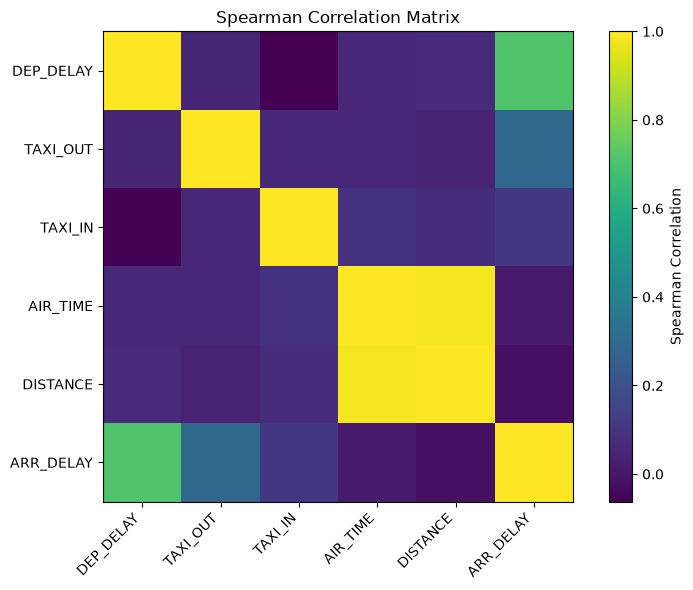

,operational_variable,absolute_spearman_rho
0,DEP_DELAY,0.707373
1,TAXI_OUT,0.291797
2,TAXI_IN,0.109491
3,DISTANCE,0.017849
4,AIR_TIME,0.015530


In [15]:
import matplotlib.pyplot as plt

spearman_columns = [
    cfg.DEPARTURE_DELAY_COLUMN,
    cfg.TAXI_OUT_COLUMN,
    cfg.TAXI_IN_COLUMN,
    cfg.AIR_TIME_COLUMN,
    cfg.DISTANCE_COLUMN,
    cfg.ARRIVAL_DELAY_COLUMN,
]

spearman_frame = extended_analysis_pdf[spearman_columns].dropna()
spearman_corr = spearman_frame.corr(method="spearman")

display(spearman_corr.round(3))

departure_delay_spearman = stat.spearman_correlation(
    spearman_frame[cfg.DEPARTURE_DELAY_COLUMN],
    spearman_frame[cfg.ARRIVAL_DELAY_COLUMN],
)
extended_results.append(
    stat.build_test_result_row(
        research_question="Diagnostic",
        hypothesis_id="Not applicable",
        null_hypothesis=(
            "Departure-delay minutes have no monotonic relationship with "
            "arrival-delay minutes."
        ),
        alternative_hypothesis=(
            "Departure-delay minutes have a monotonic relationship with "
            "arrival-delay minutes."
        ),
        factor=(
            f"Spearman({cfg.DEPARTURE_DELAY_COLUMN}, "
            f"{cfg.ARRIVAL_DELAY_COLUMN})"
        ),
        test_output=departure_delay_spearman,
        alpha=cfg.STATISTICAL_SIGNIFICANCE_ALPHA,
    )
)

plt.figure(figsize=(8, 6))
image = plt.imshow(spearman_corr, interpolation="nearest")
plt.colorbar(image, label="Spearman Correlation")
plt.xticks(
    range(len(spearman_corr.columns)),
    spearman_corr.columns,
    rotation=45,
    ha="right",
)
plt.yticks(range(len(spearman_corr.index)), spearman_corr.index)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()
plt.close()

correlation_summary = (
    spearman_corr[cfg.ARRIVAL_DELAY_COLUMN]
    .drop(cfg.ARRIVAL_DELAY_COLUMN)
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)
correlation_summary.columns = [
    "operational_variable",
    "absolute_spearman_rho",
]
display(correlation_summary)


#### Extended diagnostic interpretation

Categorical tests report Cramér's V, while the airline delay-minute comparison
reports epsilon-squared. This prevents very small effects from being described
as important merely because millions of rows produce small p-values.

Post-departure diagnostics help explain the domain but are excluded from RQ2
ranking and predictive inputs. RQ2 remains restricted to information available
at schedule time.


#### RQ4 and RQ5 — Evaluated in later notebooks

- **RQ4** is answered in Notebook 09 with global and individual TreeSHAP
  explanations of the exact final XGBoost model. It is demonstrative rather
  than a classical null-hypothesis test.
- **RQ5 / H5** is evaluated in Notebook 10 by comparing constrained
  optimization, a simple top-risk rule, and repeated random selection at the
  same effective review capacity.

Neither question is claimed as validated by the statistical tests in Notebook 05.


#### Consolidate statistical evidence

All completed hypothesis tests are combined into a single results table for reporting and downstream dashboard use.

In [16]:
extended_results_df = pd.DataFrame(extended_results)

statistical_results_pdf = pd.concat(
    [
        rq2_results_df,
        rq3_results_df,
        rq1_results_df,
        extended_results_df,
    ],
    ignore_index=True,
)


def _build_interpretation(row: pd.Series) -> str:
    text = (
        f"{row['decision']} at alpha={row['alpha']:.2f}; "
        f"effect size ({row['effect_size_label']})={row['effect_size']:.4f} "
        f"({row['effect_size_interpretation']} practical significance)"
    )
    if not row["assumptions_met"]:
        text += (
            "; NOTE: test assumptions were not fully met "
            "(see assumptions_met) - interpret with caution"
        )
    return text


statistical_results_pdf["interpretation"] = statistical_results_pdf.apply(
    _build_interpretation, axis=1
)

statistical_results_df = spark.createDataFrame(statistical_results_pdf)
display(statistical_results_df.orderBy("research_question", "factor"))

,research_question,hypothesis_id,null_hypothesis,alternative_hypothesis,factor,test_name,statistic,p_value,effect_size,effect_size_label,effect_size_interpretation,alpha,decision,assumptions_met,interpretation
0,Diagnostic,Not applicable,Departure-delay minutes have no monotonic relationship with arrival-delay minutes.,Departure-delay minutes have a monotonic relationship with arrival-delay minutes.,"Spearman(DEP_DELAY, ARR_DELAY)",Spearman Rank Correlation,0.707373,0.000000,0.707373,|Spearman rho|,Strong,0.05,Reject H0,True,Reject H0 at alpha=0.05; effect size (|Spearman rho|)=0.7074 (Strong practical significance)
1,RQ1,RQ1-Preliminary,The selected schedule-time factor is not associated with the arrival-delay outcome.,The selected schedule-time factor is associated with the arrival-delay outcome.,IS_WEEKEND,Chi-Square Test of Independence,226.050455,0.000000,0.025650,Cramer's V,Negligible,0.05,Reject H0,True,Reject H0 at alpha=0.05; effect size (Cramer's V)=0.0256 (Negligible practical significance)
2,RQ1,RQ1-Preliminary,The selected schedule-time factor is not associated with the arrival-delay outcome.,The selected schedule-time factor is associated with the arrival-delay outcome.,SEASON,Chi-Square Test of Independence,1433.780697,0.000000,0.064600,Cramer's V,Negligible,0.05,Reject H0,True,Reject H0 at alpha=0.05; effect size (Cramer's V)=0.0646 (Negligible practical significance)
3,RQ1,RQ1-Preliminary,The selected schedule-time factor is not associated with the arrival-delay outcome.,The selected schedule-time factor is associated with the arrival-delay outcome.,TIME_OF_DAY,Chi-Square Test of Independence,10585.274981,0.000000,0.175527,Cramer's V,Small,0.05,Reject H0,True,Reject H0 at alpha=0.05; effect size (Cramer's V)=0.1755 (Small practical significance)
4,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",DAY_OF_WEEK,Chi-Square Test of Independence,1306.469789,0.000000,0.061665,Cramer's V,Negligible,0.05,Reject H0,True,Reject H0 at alpha=0.05; effect size (Cramer's V)=0.0617 (Negligible practical significance)
5,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",DEP_HOUR,Chi-Square Test of Independence,235257.830992,0.000000,0.184924,Cramer's V,Small,0.05,Reject H0,True,Reject H0 at alpha=0.05; effect size (Cramer's V)=0.1849 (Small practical significance)
6,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",DEST_GROUPED,Chi-Square Test of Independence,714.948138,0.000000,0.045617,Cramer's V,Negligible,0.05,Reject H0,True,Reject H0 at alpha=0.05; effect size (Cramer's V)=0.0456 (Negligible practical significance)
7,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.",DISTANCE,Pearson Correlation,0.004392,0.010047,0.004392,|Pearson r|,Negligible,0.05,Reject H0,True,Reject H0 at alpha=0.05; effect size (|Pearson r|)=0.0044 (Negligible practical significance)
8,RQ2,H2,"Scheduling, airline, airport, route, and temporal factors have no statistically significant association with arrival-delay risk.","At least one scheduling, airline, airport, route, or temporal factor has a statistically significant association with arrival-delay risk.

#### Research question evidence summary

- **RQ1:** Preliminary association evidence only; final predictive performance
  comes from Notebooks 07–08.
- **RQ2:** The strongest schedule-time associations are identified using
  effect sizes, not p-values alone; Notebook 09 adds model-specific SHAP
  evidence without implying causation.
- **RQ3:** Statistical tests and full-population rate tables cover airlines,
  airports, routes, departure periods, and seasons.
- **RQ4:** Answered in Notebook 09.
- **RQ5 / H5:** Answered in Notebook 10.


In [17]:
validation_summary = (
    statistical_results_pdf[
        statistical_results_pdf["research_question"].isin(["RQ1", "RQ2", "RQ3"])
    ]
    .groupby("research_question", as_index=False)
    .agg(
        tests_run=("factor", "count"),
        significant_tests=(
            "decision",
            lambda values: (values == "Reject H0").sum(),
        ),
    )
)

validation_summary["supported"] = validation_summary.apply(
    lambda row: (
        "Preliminary statistical support"
        if row["research_question"] == "RQ1"
        and row["significant_tests"] > 0
        else (
            "Yes"
            if row["significant_tests"] > 0
            else "No"
        )
    ),
    axis=1,
)

display(spark.createDataFrame(validation_summary))


,research_question,tests_run,significant_tests,supported
0,RQ1,3,3,Preliminary statistical support
1,RQ2,12,12,Yes
2,RQ3,7,7,Yes


#### Save statistical analysis results

The consolidated results are registered as a managed Delta table.

In [18]:
(
    statistical_results_df.writeTo(cfg.STATISTICAL_RESULTS_TABLE)
    .using("delta")
    .createOrReplace()
)

print("Statistical analysis results saved successfully.")
print(f"Table: {cfg.STATISTICAL_RESULTS_TABLE}")
print(f"Total tests stored: {statistical_results_df.count():,}")

Statistical analysis results saved successfully.
Table: workspace.default.statistical_analysis_results
Total tests stored: 23
